## Word Embeddings

Basic tokenizer

In [8]:
import re
with open("/content/the-verdict.txt" , "r") as f:
    raw = f.read()
tokens = re.split(r'([.,:;_?!"()\']|--|\s)', raw) #basic regex
tokens = [item.strip() for item in tokens if item.strip()] #remove whitespaces
print(tokens)
print(f"Num tokens: {len(tokens)}")


['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in', 'the', 'height', 'of', 'his', 'glory', ',', 'he', 'had', 'dropped', 'his', 'painting', ',', 'married', 'a', 'rich', 'widow', ',', 'and', 'established', 'himself', 'in', 'a', 'villa', 'on', 'the', 'Riviera', '.', '(', 'Though', 'I', 'rather', 'thought', 'it', 'would', 'have', 'been', 'Rome', 'or', 'Florence', '.', ')', '"', 'The', 'height', 'of', 'his', 'glory', '"', '--', 'that', 'was', 'what', 'the', 'women', 'called', 'it', '.', 'I', 'can', 'hear', 'Mrs', '.', 'Gideon', 'Thwing', '--', 'his', 'last', 'Chicago', 'sitter', '--', 'deploring', 'his', 'unaccountable', 'abdication', '.', '"', 'Of', 'course', 'it', "'", 's', 'going', 'to', 'send', 'the', 'value', 'of', 'my', 'picture', "'", 'way', 'up', ';', 'but', 'I', 'don', "'", 't', 'think', 'of', 'that', ',

Token -> Embeddings

In [9]:
tokens_set = sorted(set(tokens))
vocab = {token:integer for integer, token in enumerate(tokens_set)}

for i, token in enumerate(vocab.items()):
    print(token)
    if i >10:
        break


('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)


Making it a class

In [10]:
class TokenizerV1:
 def __init__(self, vocab):
    self.str2int = vocab
    self.int2str = {i:s for s,i in vocab.items()}

 def encode(self, text):
    preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
    preprocessed = [item.strip() for item in preprocessed if item.strip()]
    ids = [self.str2int[s] for s in preprocessed]
    return ids

 def decode(self, ids):
    text = " ".join([self.int2str[i] for i in ids])
    text = re.sub(r'\s+([,.;:?!"()\'])', r'\1', text)
    return text

In [11]:
tokenize = TokenizerV1(vocab)
words = tokenize.encode("I found the couple at tea beneath their palm-trees; and Mrs. Gisburn's welcome was so genial that, in the ensuing weeks, I claimed it frequently. It was not that my hostess was interesting: on that point I could have given Miss Croft the fullest reassurance. It was just because she was _not_ interesting--if I may be pardoned the bull--that I found her so. For Jack, all his life, had been surrounded by interesting women: they had fostered his art, it had been reared in the hot-house of their adulation. And it was therefore instructive to note what effect the (I quote Miss Croft) was having on him.")
print(words)

[53, 469, 988, 296, 180, 975, 215, 989, 751, 9, 157, 67, 7, 38, 2, 850, 1086, 1077, 908, 485, 987, 5, 568, 988, 393, 1085, 5, 53, 268, 585, 475, 7, 56, 1077, 711, 987, 697, 555, 1077, 578, 8, 727, 987, 779, 53, 292, 530, 491, 62, 28, 988, 479, 824, 7, 56, 1077, 590, 205, 876, 1077, 114, 711, 114, 578, 6, 566, 53, 662, 198, 755, 988, 237, 6, 987, 53, 469, 539, 908, 7, 35, 57, 5, 145, 549, 622, 5, 514, 208, 963, 241, 578, 1112, 8, 994, 514, 468, 549, 174, 5, 585, 514, 208, 822, 568, 988, 556, 722, 989, 133, 7, 14, 585, 1077, 993, 577, 1016, 712, 1089, 378, 988, 3, 53, 814, 62, 28, 4, 1077, 532, 727, 546, 7]


In [12]:
tokens = sorted(list(set(tokens)))
tokens.extend(["<|endoftext|>", "<|unk|>"])
vocab = {token:i for i,token in enumerate(tokens)}
print(len(vocab.items()))

1132


In [13]:
for i, item in enumerate(list(vocab.items())[-5:]):
 print(item)

('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


In [14]:
class TokenizerV2:
 def __init__(self, vocab):
    #create maps for str2int and int2str
    self.str2int = vocab
    self.int2str = {i:s for s,i in vocab.items()}

 def encode(self, text):
    preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
    preprocessed = [item.strip() for item in preprocessed if item.strip()]
    preprocessed = [item if item in self.str2int else "<|unk|>" for item in preprocessed]
    ids = [self.str2int[s] for s in preprocessed]
    return ids

 def decode(self, ids):
    text = " ".join([self.int2str[i] for i in ids])
    text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
    return text

### Byte Pair Encoding

In [15]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")

Data sampling with a sliding window

In [16]:
with open('the-verdict.txt' , 'r') as f:
    raw = f.read()

encoded_text = tokenizer.encode(raw)
print(len(encoded_text))

5145


In [17]:
encoded_sample = encoded_text[50:] # better text for demo
context_window = 4
x = encoded_sample[:context_window]
y = encoded_sample[1:context_window+1]
print(f"x: {x} \n     y: {y}")

x: [290, 4920, 2241, 287] 
     y: [4920, 2241, 287, 257]


In [18]:
for i in range(1, context_window+1):
    x = encoded_sample[:i]
    y = encoded_sample[i]
    print(tokenizer.decode(x)," --> ", tokenizer.decode([y]))

 and  -->   established
 and established  -->   himself
 and established himself  -->   in
 and established himself in  -->   a


In [19]:
import torch
from torch.utils.data import Dataset, DataLoader

class GPTDataset(Dataset):
  #context window = window size, stride = window shift
    def __init__(self, tokenizer, text, context_window, stride):
        super().__init__()
        tokens = tokenizer.encode(text)
        self.input_tokens = []
        self.target_tokens = []

        for i in range(0, len(tokens)-context_window, stride):
            input_chunk = tokens[i:i+context_window]
            target_chunk = tokens[i+1:i+context_window+1]
            self.input_tokens.append(torch.tensor(input_chunk))
            self.target_tokens.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_tokens)

    def __getitem__(self, index):
        return self.input_tokens[index], self.target_tokens[index]

In [20]:
def create_dataloaderV1(txt, batch_size, context_window,
                         stride, shuffle, drop_last, num_workers=0):
  tokenizer = tiktoken.get_encoding("gpt2")
  dataset = GPTDataset(tokenizer, txt,  context_window, stride)
  dataloader = DataLoader(dataset,batch_size=batch_size,shuffle=shuffle,
                          drop_last=drop_last,num_workers=num_workers)
  return dataloader

In [21]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
 raw_text = f.read()

In [22]:
dataloader = create_dataloaderV1(raw_text, batch_size = 2, context_window = 4,
                                 stride = 4, drop_last=True, shuffle = False)
inputs, targets = next(iter(dataloader))
print(inputs)
print(f"Input shape:{inputs.shape}")

tensor([[  40,  367, 2885, 1464],
        [1807, 3619,  402,  271]])
Input shape:torch.Size([2, 4])


Creating token embeddings + Encoding word positions

In [23]:
vocab_size = 50257
output_dim = 256
context_window = 4

#nn.Embedding is essentially a learnable lookup table for converting tokens to vectors
#learnable matrix used for transforming data (attnention)

token_embedding_layer = torch.nn.Embedding(vocab_size, output_dim)
token_embeddings = token_embedding_layer(inputs)

print(token_embeddings.shape)

position_embedding_layer = torch.nn.Embedding(context_window, output_dim)
position_embeddings = position_embedding_layer(torch.arange(context_window))

print(position_embeddings.shape)

torch.Size([2, 4, 256])
torch.Size([4, 256])


In [24]:
input_embeddings = token_embeddings + position_embeddings
print(f"input_embedding: {input_embeddings.shape}")

input_embedding: torch.Size([2, 4, 256])


## Attention Mechanism

### Self Attention

In [25]:
from torch import nn
class SelfAttention(nn.Module):
  def __init__(self, d_in, d_out, bias):
     super().__init__()
     self.w_q = nn.Linear(d_in, d_out, bias = bias)
     self.w_k = nn.Linear(d_in, d_out, bias = bias)
     self.w_v = nn.Linear(d_in, d_out, bias = bias)

  def forward(self, x):
    q = self.w_q(x)
    k = self.w_k(x)
    v = self.w_v(x)

    product = q @ k.T
    normalised = torch.softmax(product / (k.shape[-1]**0.5), dim = -1)
    return normalised @ v

### Masked Attention

In [26]:
from torch import nn
class MaskedAttention(nn.Module):
  def __init__(self, d_in, d_out, bias, seq_length, dropout):
     super().__init__()
     self.w_q = nn.Linear(d_in, d_out, bias = bias)
     self.w_k = nn.Linear(d_in, d_out, bias = bias)
     self.w_v = nn.Linear(d_in, d_out, bias = bias)
     self.dropout = nn.Dropout(dropout)
     self.register_buffer('mask',
                          torch.triu(torch.ones(seq_length, seq_length),
                                     diagonal = 1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    q = self.w_q(x)
    k = self.w_k(x)
    v = self.w_v(x)

    product = q @ k.transpose(1, 2)
    product.masked_fill_(self.mask.bool()[:num_tokens, :num_tokens], -torch.inf)
    attn_score = torch.softmax(product / (d_in**0.5), dim=-1)
    attn_score = self.dropout(attn_score)
    return attn_score @ v

### Multi Head Attention

MultiHeaded Attention Wrapper

In [27]:
class MultiHeadedAttentionWrapper(nn.Module):
  def __init__(self, d_in, d_out, bias, seq_length,
               dropout, num_heads):
    super().__init__()
    self.heads = nn.ModuleList([MaskedAttention(d_in, d_out, bias, seq_length, dropout)
                                for _ in range(num_heads)])

  def forward(self, x):
    return torch.cat([head(x) for head in self.heads], dim = -1)

Efficient MultiHeaded Attention

In [28]:
class MultiHeadedAttention(nn.Module):
  def __init__(self, d_in, d_out, bias, dropout, num_heads, context_window):
    super().__init__()
    assert d_out % num_heads == 0, "d_out must be divisible by num_heads"
    self.d_out = d_out
    self.num_heads = num_heads
    self.head_dim = d_out//num_heads
    self.w_q = nn.Linear(d_in, d_out, bias = bias)
    self.w_k = nn.Linear(d_in, d_out, bias = bias)
    self.w_v = nn.Linear(d_in, d_out, bias = bias)
    self.out_proj = nn.Linear(d_out, d_out)
    self.dropout = nn.Dropout(dropout)
    self.register_buffer("mask",
                         torch.triu(torch.ones(context_window, context_window),
                         diagonal = 1))

  def forward(self, x):
    b, num_tokens, d_in = x.shape
    q = self.w_q(x)
    k = self.w_k(x)
    v = self.w_v(x)
    q = q.view(b, num_tokens, self.num_heads, self.head_dim)
    k = k.view(b, num_tokens, self.num_heads, self.head_dim)
    v = v.view(b, num_tokens, self.num_heads, self.head_dim)
    q = q.transpose(1, 2)
    k = k.transpose(1, 2)
    v = v.transpose(1, 2)
    #qkv = b, num_heads, num_tokens, head_dim
    product = q @ k.transpose(2,3)
    #(b, num_heads, num_tokens, head_dim) x (b, num_heads, head_dim, num_tokens)
    #=> product = (b, num_heads, num_tokens, num_tokens)
    mask = self.mask.bool()[:num_tokens, :num_tokens]
    product.masked_fill_(mask, -torch.inf)

    attn_score = torch.softmax(product / (k.shape[-1]**0.5)  , dim =  -1)
    attn_score = self.dropout(attn_score)

    context_vector = (attn_score @ v).transpose(1,2)
    #(b, num_heads, num_tokens, num_tokens) x (b, num_heads, num_tokens, head_dim)
    # => context vector = (b, num_heads, num_tokens, head_dim)
    # => context vector = (b, num_tokens, num_heads, head_dim)
    context_vector = context_vector.contiguous().view(b, num_tokens, self.d_out)
    context_vector = self.out_proj(context_vector)
    return context_vector

## Implementing GPT to generate text

In [29]:
GPT_CONFIG_124M = {
 "vocab_size": 50257, # Vocabulary size (BPE tokenizer)
 "context_window": 256, # Context length
 "emb_dim": 768, # Embedding dimension
 "n_heads": 12, # Number of attention heads
 "n_layers": 12, # Number of layers
 "drop_rate": 0.1, # Dropout rate
 "bias":False #bias term (generally not used anymore)
}

Layer Normalization

In [30]:
class LayerNorm(nn.Module):
  def __init__(self, emb_dim):
    super().__init__()
    self.scale = nn.Parameter(torch.ones(emb_dim))
    self.shift = nn.Parameter(torch.zeros(emb_dim))
  #scale and shift are learnable params the model can change if it imporves performance

  def forward(self, x):
    mean = x.mean(dim = -1, keepdim = True)
    var = x.var(dim = -1, keepdim = True, unbiased = False)
    #unbiased = false => not using bessel correction of (n-1) instead of n
    z = (x - mean) / ((var+1e-5)**0.5)
    return self.scale*z + self.shift

GELU Activation

In [31]:
class GELU(nn.Module):
  def __init__(self):
    super().__init__()

  def forward(self, x):
    return 0.5 * x * (1 + torch.tanh(torch.sqrt(torch.tensor(2.0 / torch.pi)) * (x + 0.044715 * torch.pow(x, 3))))

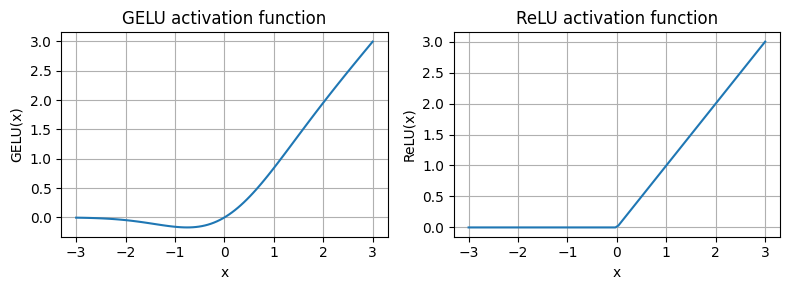

In [32]:
import matplotlib.pyplot as plt
gelu, relu = GELU(), nn.ReLU()
x = torch.linspace(-3, 3, 100)
y_gelu, y_relu = gelu(x), relu(x)
plt.figure(figsize=(8, 3))
for i, (y, label) in enumerate(zip([y_gelu, y_relu], ["GELU", "ReLU"]), 1):
 plt.subplot(1, 2, i)
 plt.plot(x, y)
 plt.title(f"{label} activation function")
 plt.xlabel("x")
 plt.ylabel(f"{label}(x)")
 plt.grid(True)
plt.tight_layout()
plt.show()

Feedforward Network

In [33]:
class FeedForward(nn.Module):
  def __init__(self, x):
    super().__init__()
    self.layers = nn.Sequential(
        nn.Linear(x["emb_dim"], 4 * x["emb_dim"]),
        GELU(),
        nn.Linear(4 * x["emb_dim"], x["emb_dim"]))

  def forward(self, x):
    return self.layers(x)

#### Transformer Block

In [34]:
GPT_CONFIG_124M

{'vocab_size': 50257,
 'context_window': 256,
 'emb_dim': 768,
 'n_heads': 12,
 'n_layers': 12,
 'drop_rate': 0.1,
 'bias': False}

In [35]:
class TransformerBlock(nn.Module):
  def __init__(self, cfg):
    #cfg is the configuration dictionary
    super().__init__()
    self.norm1 = LayerNorm(cfg["emb_dim"])
    self.norm2 = LayerNorm(cfg["emb_dim"])
    self.attn = MultiHeadedAttention(d_in = cfg["emb_dim"], d_out = cfg["emb_dim"], bias = cfg["bias"],
                                           dropout = cfg["drop_rate"], num_heads = cfg["n_heads"],
                                           context_window = cfg["context_window"])
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.ff = FeedForward(cfg)

  def forward(self, x):
    residual = x
    x = self.norm1(x)
    x = self.attn(x)
    x = self.dropout(x)
    x = residual + x
    residual = x
    x = self.norm2(x)
    x = self.ff(x)
    x = self.dropout(x)
    return residual + x

### GPT-2 Architecture

In [36]:
class GeePeeTee(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.token_embed = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.position_embed = nn.Embedding(cfg["context_window"], cfg["emb_dim"])
    self.dropout = nn.Dropout(cfg["drop_rate"])
    self.transformer = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])
    self.final_norm = LayerNorm(cfg["emb_dim"])
    self.output = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias = cfg["bias"])

  def forward(self, x):
    batch_size, seq_len = x.shape
    token_embed = self.token_embed(x)
    position_embed = self.position_embed(torch.arange(seq_len, device=x.device))
    y = token_embed + position_embed
    y = self.dropout(y)
    y = self.transformer(y)
    y = self.final_norm(y)
    logits = self.output(y)
    return logits

In [37]:
model = GeePeeTee(GPT_CONFIG_124M)
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params:,}")
total_params_gpt2 = (total_params - sum(p.numel() for p in model.output.parameters()))
print(f"Number of trainable parameters considering weight tying: {total_params_gpt2:,}")

Total number of parameters: 162,419,712
Number of trainable parameters considering weight tying: 123,822,336


### Generating Text

In [38]:
def generate_textV1(model, idx, max_tokens, context_window):
  #Crops current context if it exceeds the supported context size
  #idx = (batch, n_tokens)
  for _ in range(max_tokens): #max tokens to generate
    idx_cond = idx[:,-context_window:]
    with torch.no_grad():
      logits = model(idx_cond)

    logits = logits[:, -1,:] #focus only on last timestamp
    prob = torch.softmax(logits, dim=-1)
    idx_next = torch.argmax(prob, dim=-1, keepdim = True) #greedy implementation
    idx = torch.cat((idx, idx_next), dim=-1)
  return idx

Models first words: "**trades fabric mic enteringMarie**"


### Pretraining on unlabeled data

In [39]:
def text2token(text, tokenizer):
  encoded = tokenizer.encode(text,allowed_special={'<|endoftext|>'})
  return torch.tensor(encoded).unsqueeze(0)

def token2text(tokens, tokenizer):
  tokens = tokens.squeeze(0)
  return tokenizer.decode(tokens.tolist())

Text generation loss

In [40]:
inputs = torch.tensor([[16833, 3626, 6100],  #"every effort moves",
                        [40, 1107, 588]])    #"I really like"

targets = torch.tensor([[3626, 6100, 345 ],  #"effort moves you",
                        [1107, 588, 11311]]) #"really like chocolate"

In [41]:
with torch.no_grad():
 logits = model(inputs)
prob = torch.softmax(logits, dim=-1)

#below not req but still shown for clarity
token_ids = torch.argmax(prob, dim=-1, keepdim=True)
print(prob.shape)
print("Token IDs:\n", token_ids)

torch.Size([2, 3, 50257])
Token IDs:
 tensor([[[34878],
         [28218],
         [25111]],

        [[27371],
         [24531],
         [49938]]])


In [42]:
target_prob1 = prob[[0], [0, 1, 2], targets[0]]
target_prob2 = prob[[1], [0, 1, 2], targets[1]]
print(target_prob1)
print(target_prob2)

tensor([8.6389e-06, 2.0973e-05, 1.2813e-05])
tensor([3.8855e-05, 2.7862e-05, 1.6473e-05])


In [43]:
log_prob = torch.log(torch.cat((target_prob1, target_prob2)))
log_prob

tensor([-11.6592, -10.7723, -11.2651, -10.1557, -10.4882, -11.0138])

In [44]:
avg_log_prob = torch.mean(log_prob)
avg_log_prob

tensor(-10.8924)

In [45]:
neg_avg_log_prob = avg_log_prob * -1

print(neg_avg_log_prob)

tensor(10.8924)


In [46]:
logits.shape

torch.Size([2, 3, 50257])

In [47]:
logits_flat = logits.flatten(0,1)
targets_flat = targets.flatten()
print("Flattened logits:", logits_flat.shape)
print("Flattened targets:", targets_flat.shape)

Flattened logits: torch.Size([6, 50257])
Flattened targets: torch.Size([6])


In [48]:
loss = torch.nn.functional.cross_entropy(logits_flat, targets_flat)
loss

tensor(10.8924)

 Calculating the training and validation set losses

In [49]:
path = "/content/the-verdict.txt"
with open(path, "r", encoding = "utf-8") as f:
  text_data = f.read()

In [50]:
train_ratio = 0.9
split = int(train_ratio*len(text_data))
train_data = text_data[:split]
test_data = text_data[split:]

In [51]:
train_dataloader = create_dataloaderV1(train_data, batch_size = 2, context_window = GPT_CONFIG_124M['context_window'],
                                       stride = GPT_CONFIG_124M['context_window'],shuffle = True,
                                       drop_last = True)

test_dataloader = create_dataloaderV1(test_data, batch_size = 2, context_window = GPT_CONFIG_124M['context_window'],
                                       stride = GPT_CONFIG_124M['context_window'],shuffle = False,
                                       drop_last = False)

In [52]:
def loss_batch(input, target, model, device):
  input = input.to(device)
  target = target.to(device)
  logits = model(input)
  loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target.flatten())
  return loss


def loss_loader(dataloader, model, device, num_batches=None):
  #num_batches gives control over how many batches to run on
  total_loss = 0

  if len(dataloader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(dataloader)
  else:
    num_batches = min(num_batches, len(dataloader))
    for i , (input, target) in enumerate(dataloader):
      if i < num_batches:
        loss = loss_batch(input, target, model, device)
        total_loss += loss.item()
      else:
        break
  return total_loss/num_batches

In [53]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
with torch.no_grad():
  train_loss = loss_loader(train_dataloader, model, device)
  valid_loss = loss_loader(test_dataloader, model, device)
print(f"Train Loss: {train_loss} | Test Loss: {valid_loss}")

Train Loss: 0.0 | Test Loss: 0.0


#### Training an LLM

In [54]:
def trainLLM(model, train_loader, val_loader, optimizer, device,
             epochs, eval_freq, eval_iter, start_context, tokenizer):
  train_loss_list, valid_loss_list, tokens_seen_list = [], [], []
  tokens_seen, global_step = 0 , -1
  for epoch in range(epochs):
    #Training
    model.train()
    for input, target in train_dataloader: #will run no. of batches times
      optimizer.zero_grad()
      loss = loss_batch(input, target, model, device)
      loss.backward()
      optimizer.step()
      tokens_seen += input.numel()
      global_step += 1

    #Evaluation Step (optional)
      if global_step % eval_freq == 0:
        train_loss, val_loss = evaluate_model(model, train_dataloader, test_dataloader, device, eval_iter)
        train_loss_list.append(train_loss)
        valid_loss_list.append(val_loss)
        tokens_seen_list.append(tokens_seen)
        print(f"Epoch {epoch+1} (Step {global_step:06d}): | Train loss: {train_loss:.3f} | Val loss: {val_loss:.3f}")

      generate_sample(model, tokenizer, device, start_context)
  return train_loss_list, valid_loss_list, tokens_seen_list

In [55]:
def evaluate_model(model, train_dataloader, test_dataloader, device, eval_iter):
  model.eval()
  train_loss = loss_loader(train_dataloader, model, device, eval_iter)
  test_loss = loss_loader(test_dataloader, model, device, eval_iter)
  model.train()
  return train_loss, test_loss

def generate_sample(model, tokenizer, device, start_context):
  model.eval()
  context_window = model.position_embed.weight.shape[0]
  encoded = text2token(start_context, tokenizer).to(device)
  with torch.no_grad():
    id = generate_textV1(model, encoded, 50, context_window)
  decoded = token2text(id, tokenizer)
  print(decoded.replace("\n"," "))
  model.train()

In [69]:
model = GeePeeTee(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(),lr=0.0004, weight_decay=0.1)
epochs = 10
train_loss, val_loss, tokens_seen = trainLLM(model, train_dataloader, train_dataloader, optimizer, device,
                                                 epochs=epochs, eval_freq=5, eval_iter=5,
                                                 start_context="Once upon a time there lived a", tokenizer=tokenizer)

Epoch 1 (Step 000000): | Train loss: 9.866 | Val loss: 10.068
Once upon a time there lived a                                                  
Once upon a time there lived a,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Once upon a time there lived a,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Once upon a time there lived a,,,,.                                             
Once upon a time there lived a,,.                                               
Epoch 1 (Step 000005): | Train loss: 8.160 | Val loss: 8.433
Once upon a time there lived a,,,,.                                             
Once upon a time there lived a,,.                                               
Once upon a time there lived a, the.                                               
Once upon a time there lived a, the, the.                                             
Once upon a time there lived a, the, the.                                             
Epoch 2 (Step 000010): | Train loss: 6.781 | Val los

In [70]:
model.to('cpu')
model.eval()

GeePeeTee(
  (token_embed): Embedding(50257, 768)
  (position_embed): Embedding(256, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (transformer): Sequential(
    (0): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): MultiHeadedAttention(
        (w_q): Linear(in_features=768, out_features=768, bias=False)
        (w_k): Linear(in_features=768, out_features=768, bias=False)
        (w_v): Linear(in_features=768, out_features=768, bias=False)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (ff): FeedForward(
        (layers): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): TransformerBlock(
      (norm1): LayerNorm()
      (norm2): LayerNorm()
      (attn): Mul

In [71]:
token_ids = generate_textV1(model=model, idx=text2token("Every effort moves you", tokenizer),
                            max_tokens=25,context_window=GPT_CONFIG_124M["context_window"])
print("Output text:\n", token2text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

I looked up the. Gisburn--as such--had not to my work, that one longed


 Strategies to control randomness

1.   Temperature scaling
2.   Top-k sampling   



### Modified text generation

In [72]:
def generate(model, input, max_new_tokens, context_window,
             temperature=0.0, top_k=None, eos_id=None):
  for _ in range(max_new_tokens):
    cropped = input[:, -context_window:]  #only uses last len(context_window) tokens
    with torch.no_grad():
      logits = model(cropped)
    logits = logits[:, -1, :]
    #input/logits shape = (batch, tokens)
    if top_k is not None:
      top_logits, _ = torch.topk(logits, top_k)
      min_val = top_logits[:, -1]
      logits = torch.where(logits < min_val, torch.tensor(float('-inf')).to(logits.device), logits)

    if temperature > 0.0:
      logits = logits / temperature
      probs = torch.softmax(logits, dim=-1)
      next = torch.multinomial(probs, num_samples=1)
    else:
      next = torch.argmax(logits, dim=-1, keepdim=True)

    if next == eos_id:
      break
    input = torch.cat((input, next), dim=1)
  return input

## **Results**:

trades fabric mic enteringMarie

### to

Once upon a time there lived a,,,,,,,,,,,,,,,, I, and,, I, and,,,,, I,, I,,.,,,, I,,,,,, I,,

### to

Once upon a time there lived a's tears I felt able to face the fact with equanimity. Gisburn's an awful simpleton, you know, Mrs. Stroud. Her only idea was to have him done by a fashionable painter--that I found her so.

Sensible? No

Coherent? **Yes**.

